In [2]:
# ── Install (run once) ────────────────────────────────────────────────────────
# !pip install checkov pandas pyarrow datasets tqdm plotly kaleido --quiet

import os, json, subprocess, tempfile, textwrap, re
from pathlib import Path

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Column name constants (match parquet schema) ─────────────────────────────
_CODE_COL   = 'Reference output'
_PROMPT_COL = 'Prompt'
_DIFF_COL   = 'Difficulty'
_INTENT_COL = 'Intent'
_REGO_COL   = 'Rego intent'
_RES_COL    = 'Resource'

OUTPUT_DIR = Path('output/checkov_audit')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')


✅ Imports OK


In [4]:
# from datasets import load_dataset
# ds  = load_dataset("autoiac-project/iac-eval", split="test")
# df  = ds.to_pandas()

PARQUET_GLOB = './iac_benchmark/iac_eval_hf/data/train.parquet'           # ← adjust path if needed
df = pd.read_parquet(PARQUET_GLOB)

# Normalise difficulty to int if stored as string ("Level 1" → 1)
if df[_DIFF_COL].dtype == object:
    df[_DIFF_COL] = df[_DIFF_COL].str.extract(r'(\d)').astype(int)

# Drop rows with no reference code
df = df.dropna(subset=[_CODE_COL]).reset_index(drop=True)

print(f'Loaded {len(df):,} scenarios  |  columns: {list(df.columns)}')
df.head(5)

Loaded 458 scenarios  |  columns: ['Resource', 'Prompt', 'Rego intent', 'Difficulty', 'Reference output', 'Intent']


,Resource,Prompt,Rego intent,Difficulty,Reference output,Intent
0,"aws_cloudwatch_log_group, aws_cloudwatch_log_r...",Configure a query log that can create a log st...,package terraform.validation\n\ndefault is_con...,5,terraform {\n required_providers {\n aws =...,"Has one ""aws_route53_zone"" resource\n with ..."
1,"aws_route53_vpc_association_authorization, aws...",Configure a valid Route 53 zone association re...,package terraform.validation\n\ndefault is_con...,3,"provider ""aws"" {\n region = ""us-east-1""\n}\...","Has multiple ""aws_vpc"" resource\n with a sp..."
2,"aws_elb, aws_route53_record, aws_route53_zone",Configure a Route 53 record with an Elastic Lo...,package terraform.validation\n\ndefault is_con...,3,"provider ""aws"" {\n region = ""us-east-1""\n}\n\...","Has one ""aws_route53_zone"" resource\n with ..."
3,"aws_db_instance, aws_db_instance, aws_db_insta...","Using route 53 resources, configure a weighted...",package terraform.validation\n\ndefault is_con...,6,terraform {\n required_providers {\n aws =...,"Has one ""aws_route53_zone"" resource\n with ..."
4,"aws_db_instance, aws_db_instance, aws_db_subne...",Configure Route 53 to return different databas...,package terraform.validation\n\ndefault is_con...,6,terraform {\n required_providers {\n aws =...,"Has one ""aws_vpc"" resource\n with a specifi..."


In [ ]:
# import subprocess, sys

# # Uninstall current broken install
# subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'checkov', '-y'], check=False)

# # Reinstall pinned to a known-good version for Python 3.12
# subprocess.run([
#     sys.executable, '-m', 'pip', 'install',
#     'checkov==3.2.350',          # last stable release before yaml-loader refactor
#     'pyyaml>=6.0.1',
#     'bc-python-hcl2>=0.3.51',
#     '--force-reinstall',
#     '--quiet',
# ], check=True)

# # Verify
# result = subprocess.run(['checkov', '--version'], capture_output=True, text=True)
# print('Checkov version:', result.stdout.strip())
# print('stderr:', result.stderr.strip())


In [ ]:
# ── Diagnostic: inspect raw Checkov output for one template ──────────────────
sample_code = df[_CODE_COL].iloc[0]

with tempfile.TemporaryDirectory() as tmpdir:
    tf_path = Path(tmpdir) / 'main.tf'
    tf_path.write_text(str(sample_code), encoding='utf-8')

    proc = subprocess.run(
        ['checkov', '-f', str(tf_path), '--framework', 'terraform', '-o', 'json', '--quiet', '--compact'],
        capture_output=True, text=True, timeout=60
    )
    print('=== RETURN CODE ===')
    print(proc.returncode)
    print('=== STDOUT (first 3000 chars) ===')
    print(proc.stdout[:3000])
    print('=== STDERR (first 1000 chars) ===')
    print(proc.stderr[:1000])

In [ ]:
def run_checkov(tf_code: str, timeout: int = 60) -> dict:
    result = {
        'checkov_passed':      False,
        'checkov_error':       None,
        'total_checks':        0,
        'passed_checks':       0,
        'failed_checks':       0,
        'policy_pass_rate':    None,
        'filtered_compliance': False,
        'severity_high':       0,
        'severity_medium':     0,
        'severity_low':        0,
        'severity_info':       0,
        'violations':          [],
        'cis_violations':      [],
        'violation_ids':       [],
        'violation_names':     [],
        'checkov_log':         '',
    }

    with tempfile.TemporaryDirectory() as tmpdir:
        tf_path = Path(tmpdir) / 'main.tf'
        tf_path.write_text(str(tf_code), encoding='utf-8')

        cmd = [
            'checkov',
            '-f', str(tf_path),
            '--framework', 'terraform',
            '-o', 'json',
            '--quiet',
            '--compact',
            '--skip-download',        # avoids registry fetch that can emit extra text
        ]

        try:
            proc = subprocess.run(
                cmd, capture_output=True, text=True, timeout=timeout
            )
        except subprocess.TimeoutExpired:
            result['checkov_error'] = 'TimeoutExpired'
            return result
        except FileNotFoundError:
            result['checkov_error'] = 'checkov_not_found'
            return result
        except Exception as e:
            result['checkov_error'] = str(e)
            return result

        raw_stdout = proc.stdout
        raw_stderr = proc.stderr
        result['checkov_log'] = raw_stdout[:4000] + raw_stderr[:500]

        # ── Robust JSON extraction ────────────────────────────────────────
        # Checkov sometimes emits log lines / ANSI codes before the JSON blob.
        # Strategy: find the first '[' or '{' that starts a valid JSON structure.
        raw = None

        # Try 1: direct parse (clean output)
        try:
            raw = json.loads(raw_stdout)
        except json.JSONDecodeError:
            pass

        # Try 2: strip ANSI escape codes then parse
        if raw is None:
            clean = re.sub(r'\x1b\[[0-9;]*m', '', raw_stdout)
            try:
                raw = json.loads(clean)
            except json.JSONDecodeError:
                pass

        # Try 3: find first JSON array or object in the output (skip leading log lines)
        if raw is None:
            for start_char, end_char in [('[', ']'), ('{', '}')]:
                idx = raw_stdout.find(start_char)
                if idx != -1:
                    candidate = raw_stdout[idx:]
                    # trim to balanced close
                    depth, end_idx = 0, -1
                    for i, ch in enumerate(candidate):
                        if ch == start_char: depth += 1
                        elif ch == end_char:
                            depth -= 1
                            if depth == 0:
                                end_idx = i + 1
                                break
                    if end_idx != -1:
                        try:
                            raw = json.loads(candidate[:end_idx])
                            break
                        except json.JSONDecodeError:
                            pass

        if raw is None:
            result['checkov_error'] = 'json_parse_failed'
            result['checkov_log']   = raw_stdout[:2000] + '\nSTDERR: ' + raw_stderr[:500]
            return result

        # ── Normalise: Checkov v2 wraps in list, v3 may return dict directly ─
        if isinstance(raw, list):
            # filter to terraform results only
            tf_results = [r for r in raw if r.get('check_type') == 'terraform']
            raw = tf_results[0] if tf_results else (raw[0] if raw else {})

        # ── Summary counts ─────────────────────────────────────────────────
        summary = raw.get('summary', {})
        result['passed_checks'] = int(summary.get('passed',  0))
        result['failed_checks'] = int(summary.get('failed',  0))
        result['total_checks']  = result['passed_checks'] + result['failed_checks']

        if result['total_checks'] > 0:
            result['policy_pass_rate'] = round(
                result['passed_checks'] / result['total_checks'], 4
            )
        result['filtered_compliance'] = (result['total_checks'] > 0
                                         and result['failed_checks'] == 0)

        # ── Map failed checks ──────────────────────────────────────────────
        _SEV_MAP = {
            'HIGH': 'severity_high', 'MEDIUM': 'severity_medium',
            'LOW': 'severity_low',   'INFO': 'severity_info',
            'INFORMATIONAL': 'severity_info',
        }

        for chk in raw.get('results', {}).get('failed_checks', []):
            sev = (chk.get('severity') or 'NONE').upper()
            check_id   = chk.get('check_id',   '')
            check_name = chk.get('check_name', check_id)

            item = {
                'check_id':      check_id,
                'check_name':    check_name,
                'resource':      chk.get('resource', ''),
                'resource_type': chk.get('resource', '').split('.')[0],
                'severity':      sev,
                'guideline':     chk.get('guideline', ''),
                'file_line':     chk.get('file_line_range', []),
            }
            result['violations'].append(item)
            result['violation_ids'].append(check_id)
            result['violation_names'].append(check_name)
            result[_SEV_MAP.get(sev, 'severity_low')] += 1

            if re.match(r'CKV_AWS_', check_id):
                result['cis_violations'].append(check_id)

        result['checkov_passed'] = result['filtered_compliance']
        return result


In [ ]:
# ── Batch scan ────────────────────────────────────────────────────────────────
checkov_results = []

for code in tqdm(df[_CODE_COL], desc='Checkov scan', unit='template'):
    checkov_results.append(run_checkov(str(code)))

# ── Expand flat scalar columns into the main dataframe ───────────────────────
SCALAR_COLS = [
    'checkov_passed', 'checkov_error',
    'total_checks', 'passed_checks', 'failed_checks',
    'policy_pass_rate', 'filtered_compliance',
    'severity_high', 'severity_medium', 'severity_low', 'severity_info',
    'checkov_log',
]

df_chk = pd.DataFrame(checkov_results)
for col in SCALAR_COLS:
    df[col] = df_chk[col]

# Keep list columns separate (not great in a flat DataFrame)
df['violation_ids']   = df_chk['violation_ids']
df['violation_names'] = df_chk['violation_names']
df['violations_json'] = df_chk['violations'].apply(json.dumps)  # serialisable
df['cis_violations']  = df_chk['cis_violations']

# ── Severity-weighted violation score (HIGH=3, MED=2, LOW=1, INFO=0.5) ────────
df['swvs'] = (
    df['severity_high']   * 3 +
    df['severity_medium'] * 2 +
    df['severity_low']    * 1 +
    df['severity_info']   * 0.5
)

print(f"\nCheckov scan complete")
print(f"  Templates scanned          : {len(df):,}")
print(f"  Fully compliant (FCR)      : {df['filtered_compliance'].sum():,}  "
      f"({df['filtered_compliance'].mean()*100:.1f}%)")
print(f"  Mean policy pass rate (PPR): {df['policy_pass_rate'].mean()*100:.1f}%")
print(f"  Total violations found     : {df['failed_checks'].sum():,}")


In [ ]:
# Save full results (list columns serialised as JSON strings)
SAVE_COLS = list(df.columns)
save_df = df.copy()
# list-type cols → JSON string for CSV compatibility
for lc in ['violation_ids', 'violation_names', 'cis_violations']:
    save_df[lc] = save_df[lc].apply(json.dumps)

save_df[SAVE_COLS].to_csv(OUTPUT_DIR / 'iac_eval_checkov_results.csv', index=False)
save_df[SAVE_COLS].to_parquet(OUTPUT_DIR / 'iac_eval_checkov_results.parquet', index=False)
print(f'Saved enriched dataset → {OUTPUT_DIR}')
print(save_df.columns)
save_df[['Prompt','Reference output','checkov_passed', 'checkov_error', 'total_checks',
       'passed_checks', 'failed_checks', 'policy_pass_rate',
       'filtered_compliance', 'severity_high', 'severity_medium',
       'severity_low', 'severity_info', 'checkov_log', 'violation_ids',
       'violation_names', 'violations_json', 'cis_violations', 'swvs']].head()

In [ ]:
# ── Explode violation_ids to get per-check counts ─────────────────────────────
all_violations = (
    df[['violation_ids', 'violation_names', _DIFF_COL, _RES_COL]]
    .explode('violation_ids')
    .rename(columns={'violation_ids': 'check_id'})
    .dropna(subset=['check_id'])
    .query("check_id != ''")
)

# Attach human-readable names
name_pairs = []
for _, row in df.iterrows():
    ids   = row['violation_ids']   if isinstance(row['violation_ids'],   list) else []
    names = row['violation_names'] if isinstance(row['violation_names'], list) else []
    name_pairs.extend(zip(ids, names))

name_map = dict(name_pairs)  # last-write-wins for duplicates, which is fine

all_violations['check_name'] = all_violations['check_id'].map(name_map)

# ── Top violations overall ────────────────────────────────────────────────────
top_violations = (
    all_violations.groupby(['check_id', 'check_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(20)
)

# ── Violations by difficulty ───────────────────────────────────────────────────
vuln_by_diff = (
    all_violations.groupby([_DIFF_COL, 'check_id'])
    .size()
    .reset_index(name='count')
)

# ── Summary table by difficulty ────────────────────────────────────────────────
# policy_pass_rate is None for templates with 0 applicable checks → cast to float first
df['policy_pass_rate'] = pd.to_numeric(df['policy_pass_rate'], errors='coerce')

summary_table = (
    df.groupby(_DIFF_COL)
    .agg(
        scenarios          = (_CODE_COL,            'count'),
        pct_compliant      = ('filtered_compliance', 'mean'),
        mean_ppr           = ('policy_pass_rate',    'mean'),   # NaN-safe mean
        mean_violations    = ('failed_checks',       'mean'),
        mean_swvs          = ('swvs',                'mean'),
        total_high         = ('severity_high',       'sum'),
        total_medium       = ('severity_medium',     'sum'),
        total_low          = ('severity_low',        'sum'),
    )
    .reset_index()
)

# Safe percentage conversion – fillna(0) handles groups with no applicable checks
summary_table['pct_compliant'] = (summary_table['pct_compliant'].fillna(0) * 100).round(1)
summary_table['mean_ppr']      = (summary_table['mean_ppr'].fillna(0)      * 100).round(1)
summary_table['mean_violations']= summary_table['mean_violations'].round(1)
summary_table['mean_swvs']      = summary_table['mean_swvs'].round(2)

print(summary_table.to_string(index=False))



In [ ]:
import json as _json

# ── 1. Top 15 Vulnerabilities (horizontal bar) ────────────────────────────────
top15 = top_violations.head(15).sort_values('count')
label = top15['check_id'] + ' – ' + top15['check_name'].fillna('')
label = label.str[:55]   # truncate long names

fig1 = go.Figure(go.Bar(
    x=top15['count'], y=label, orientation='h',
    text=top15['count'], textposition='outside',
))
fig1.update_layout(
    title=dict(text=(
        'Top 15 Checkov Violations in IaC-Eval<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval (autoiac-project) | Checkov terraform framework"
        "</span>"
    )),
    xaxis_title='# Occurrences',
    yaxis_title='Policy Check',
    margin=dict(l=380, r=60, t=100, b=60),
    height=600,
)
fig1.update_traces(cliponaxis=False)
fig1.show()
fig1.write_image(str(OUTPUT_DIR / 'top15_violations.png'))
with open(str(OUTPUT_DIR / 'top15_violations.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Top 15 Checkov policy violations across IaC-Eval templates',
                'description': 'Horizontal bar chart counting each failed Checkov check'}, f)

# ── 2. Severity breakdown (stacked bar by difficulty) ─────────────────────────
sev_cols   = ['severity_high', 'severity_medium', 'severity_low', 'severity_info']
sev_labels = ['High', 'Medium', 'Low', 'Info']
sev_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#aec7e8']

sev_by_diff = df.groupby(_DIFF_COL)[sev_cols].sum().reset_index()

fig2 = go.Figure()
for col, label2, color in zip(sev_cols, sev_labels, sev_colors):
    fig2.add_bar(
        x=sev_by_diff[_DIFF_COL].astype(str),
        y=sev_by_diff[col],
        name=label2,
        marker_color=color,
    )
fig2.update_layout(
    barmode='stack',
    title=dict(text=(
        'Violation Severity by Difficulty Level<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | stacked = HIGH / MEDIUM / LOW / INFO"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='# Violations',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig2.show()
fig2.write_image(str(OUTPUT_DIR / 'severity_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'severity_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Violation severity distribution by DPIaC-Eval difficulty',
                'description': 'Stacked bar chart with HIGH/MEDIUM/LOW/INFO per difficulty level'}, f)

# ── 3. Policy Pass Rate distribution (box plot by difficulty) ─────────────────
fig3 = px.box(
    df.dropna(subset=['policy_pass_rate']),
    x=df.dropna(subset=['policy_pass_rate'])[_DIFF_COL].astype(str),
    y='policy_pass_rate',
    color=df.dropna(subset=['policy_pass_rate'])[_DIFF_COL].astype(str),
    points='outliers',
    category_orders={_DIFF_COL: [str(i) for i in range(1, 6)]},
)
fig3.update_layout(
    title=dict(text=(
        'Policy Pass Rate (PPR) by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | IaCGen baseline PPR = 75.3 %"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='Policy Pass Rate',
    showlegend=False,
)
fig3.update_yaxes(tickformat='.0%')
fig3.show()
fig3.write_image(str(OUTPUT_DIR / 'ppr_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'ppr_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Policy pass rate spread per difficulty level',
                'description': 'Box plot of PPR showing IQR + outliers by difficulty'}, f)

# ── 4. Filtered Compliance Rate (FCR) per difficulty (bar) ────────────────────
fcr = (
    df.groupby(_DIFF_COL)['filtered_compliance']
    .mean()
    .reset_index()
    .rename(columns={'filtered_compliance': 'fcr'})
)
fcr['fcr_pct'] = (fcr['fcr'] * 100).round(1)

fig4 = go.Figure(go.Bar(
    x=fcr[_DIFF_COL].astype(str),
    y=fcr['fcr_pct'],
    text=fcr['fcr_pct'].astype(str) + '%',
    textposition='outside',
))
fig4.add_hline(
    y=8.4, line_dash='dash', line_color='red',
    annotation_text='IaCGen FCR baseline 8.4 %',
    annotation_position='top right',
)
fig4.update_layout(
    title=dict(text=(
        'Filtered Compliance Rate (FCR) by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | red dash = IaCGen 8.4 % baseline"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='FCR (%)',
)
fig4.update_traces(cliponaxis=False)
fig4.show()
fig4.write_image(str(OUTPUT_DIR / 'fcr_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'fcr_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Filtered compliance rate per difficulty vs IaCGen baseline',
                'description': 'Bar chart of FCR% by difficulty with IaCGen 8.4% reference line'}, f)

# ── 5. Top 10 violated check IDs by Resource type (heat map) ──────────────────
top10_ids = top_violations['check_id'].head(10).tolist()
heat_df   = all_violations[all_violations['check_id'].isin(top10_ids)]
heat_piv  = (
    heat_df.groupby([_RES_COL, 'check_id'])
    .size()
    .unstack(fill_value=0)
)
# Keep top 12 resource types by total violations
heat_piv = heat_piv.loc[heat_piv.sum(axis=1).nlargest(12).index]

fig5 = go.Figure(go.Heatmap(
    z=heat_piv.values,
    x=heat_piv.columns.tolist(),
    y=heat_piv.index.tolist(),
    colorscale='YlOrRd',
    text=heat_piv.values,
    texttemplate='%{text}',
))
fig5.show()
fig5.update_layout(
    title=dict(text=(
        'Violation Heatmap: Resource × Check ID<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | top-12 resource types, top-10 check IDs"
        "</span>"
    )),
    xaxis_title='Check ID',
    yaxis_title='Resource Type',
    margin=dict(l=200, r=40, t=100, b=120),
    height=600,
)
fig5.write_image(str(OUTPUT_DIR / 'violation_heatmap.png'))
with open(str(OUTPUT_DIR / 'violation_heatmap.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Heatmap of top-10 Checkov violations per AWS resource type',
                'description': 'Cell values = raw violation count; rows = resource, cols = check ID'}, f)

# ── 6. Compliance summary styled table ────────────────────────────────────────
tbl = summary_table.copy()
tbl[_DIFF_COL] = tbl[_DIFF_COL].map({
    1: 'L1 (<50 LoC)', 2: 'L2 (50–100)',
    3: 'L3 (100–150)', 4: 'L4 (150–200)', 5: 'L5 (>200)'
})

n = len(tbl)
fills = [['#1e2130' if i % 2 == 0 else '#272b3f' for i in range(n)]] * len(tbl.columns)
hdrs  = ['Difficulty', '#Scenarios', 'FCR %', 'PPR %',
         'Mean Violations', 'SWVS', '⬆ High', '⬆ Med', '⬆ Low']

fig6 = go.Figure(go.Table(
    columnwidth=[130, 80, 70, 70, 110, 80, 70, 70, 70],
    header=dict(
        values    =[f'<b>{h}</b>' for h in hdrs],
        fill_color='#0f1117', font=dict(color='white', size=12),
        align='center', height=36,
    ),
    cells=dict(
        values    =[tbl[c].tolist() for c in tbl.columns],
        fill_color=fills,
        font=dict(color='#e0e0e0', size=11),
        align=['left'] + ['center'] * (len(hdrs) - 1),
        height=32,
    ),
))
fig6.update_layout(
    title=dict(text=(
        'Security Compliance Summary by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | FCR=Filtered Compliance, PPR=Policy Pass Rate, SWVS=Severity-Weighted Score"
        "</span>"
    )),
    margin=dict(l=20, r=20, t=100, b=20), height=340,
)
fig6.show()
fig6.write_image(str(OUTPUT_DIR / 'compliance_summary_table.png'))
with open(str(OUTPUT_DIR / 'compliance_summary_table.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Checkov security compliance summary per difficulty level',
                'description': 'Table with FCR, PPR, mean violations, SWVS, and severity counts'}, f)

print('All 6 figures saved →', OUTPUT_DIR)


In [ ]:
total = len(df)
compliant = df['filtered_compliance'].sum()
avg_ppr   = df['policy_pass_rate'].mean()
total_viol = df['failed_checks'].sum()
top3 = top_violations.head(3)[['check_id', 'check_name', 'count']].to_string(index=False)

print(f"""
╔══════════════════════════════════════════════════════╗
║              CHECKOV AUDIT  –  KEY METRICS           ║
╠══════════════════════════════════════════════════════╣
  Templates scanned            : {total:>6,}
  Filtered Compliance Rate FCR : {compliant/total*100:>6.1f} %
  Mean Policy Pass Rate   PPR  : {avg_ppr*100:>6.1f} %
  Total violations found       : {total_viol:>6,}
  Mean violations / template   : {df['failed_checks'].mean():>6.1f}
  HIGH severity count          : {df['severity_high'].sum():>6,}
  MEDIUM severity count        : {df['severity_medium'].sum():>6,}
  LOW severity count           : {df['severity_low'].sum():>6,}
╠══════════════════════════════════════════════════════╣
  TOP 3 VIOLATIONS
{top3}
╚══════════════════════════════════════════════════════╝
""")


In [ ]:
# ── Top violations per resource type ──────────────────────────────────────────
import ast

# 1. Explode violation_ids and violation_names in parallel
#    Both lists are aligned (same index = same check), so we zip them.
df_exploded = df[[_RES_COL, 'violation_ids', 'violation_names']].copy()

# Build a long-form dataframe: one row per (scenario, violation)
rows = []
for _, row in df_exploded.iterrows():
    ids   = row['violation_ids']   if isinstance(row['violation_ids'],   list) else []
    names = row['violation_names'] if isinstance(row['violation_names'], list) else []
    # Handle JSON-string form if loaded from saved CSV
    if isinstance(ids,   str): ids   = json.loads(ids)
    if isinstance(names, str): names = json.loads(names)
    for cid, cname in zip(ids, names):
        if cid:  # skip empty
            rows.append({'resource': row[_RES_COL], 'check_id': cid, 'check_name': cname})

df_long = pd.DataFrame(rows)

# 2. Explode multi-resource rows (Resource col is comma-separated like
#    "aws_s3_bucket, aws_iam_role") → one resource type per row
df_long['resource'] = df_long['resource'].str.split(',')
df_long = df_long.explode('resource')
df_long['resource'] = df_long['resource'].str.strip()

# 3. Count occurrences per (resource_type, check_id)
violation_counts = (
    df_long.groupby(['resource', 'check_id', 'check_name'])
    .size()
    .reset_index(name='count')
)

# 4. Keep top-N violations per resource (by count), then top-K resources overall
TOP_VIOLATIONS_PER_RESOURCE = 5
TOP_RESOURCES = 10

top_per_resource = (
    violation_counts
    .sort_values('count', ascending=False)
    .groupby('resource')
    .head(TOP_VIOLATIONS_PER_RESOURCE)
)

# Rank resources by their total violation count, keep top-K
resource_totals = (
    violation_counts.groupby('resource')['count']
    .sum()
    .sort_values(ascending=False)
)
top_resources = resource_totals.head(TOP_RESOURCES).index.tolist()

plot_df = (
    top_per_resource[top_per_resource['resource'].isin(top_resources)]
    .copy()
)

# Short label: "CKV_AWS_338" rather than the full description for readability
plot_df['label'] = plot_df['check_id']

# 5. Plot: faceted horizontal bar — one subplot per resource type
fig = px.bar(
    plot_df.sort_values(['resource', 'count'], ascending=[True, True]),
    x='count',
    y='label',
    color='resource',
    facet_col='resource',
    facet_col_wrap=2,
    orientation='h',
    text='count',
    hover_data={'check_name': True, 'check_id': True, 'count': True, 'resource': False},
    title='Top Checkov Violations per AWS Resource Type<br>'
          '<span style="font-size:13px;font-weight:normal">'
          f'Top {TOP_RESOURCES} resources · Top {TOP_VIOLATIONS_PER_RESOURCE} violations each'
          '</span>',
    color_discrete_sequence=px.colors.qualitative.Plotly,
)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    height=300 * ((len(top_resources) + 1) // 2),
    showlegend=False,
    margin=dict(t=120, l=20, r=20, b=60),
)
# Remove redundant "resource=" prefix from facet titles
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
# Each facet has independent y-axis so bars don't crowd
fig.update_yaxes(matches=None, showticklabels=True)
fig.update_xaxes(matches=None)

fig.write_image(OUTPUT_DIR / 'top_violations_per_resource.png', scale=2)
fig.show()

print(f"\nTop {TOP_RESOURCES} resources by total violations:")
print(resource_totals.head(TOP_RESOURCES).to_string())


# Trivy

In [28]:
# ── Trivy diagnostic: inspect raw output for sample[0] ───────────────────────
import shutil, tempfile

sample_code = df[_CODE_COL].iloc[0]
_tmpdir = tempfile.mkdtemp()
try:
    _tf = Path(_tmpdir) / 'main.tf'
    _tf.write_text(str(sample_code), encoding='utf-8')

    _proc = subprocess.run(
        ['trivy', 'config', '--format', 'json', str(_tmpdir)],
        capture_output=True, text=True, timeout=90
    )
    print('=== VERSION ===')
    subprocess.run(['trivy', '--version'], capture_output=False)
    print('\n=== RETURN CODE ===', _proc.returncode)
    print('=== STDOUT ===')
    # print(_proc.stdout[:3000])
    print(_proc.stdout)
    print('=== STDERR ===')
    print(_proc.stderr[:500])
finally:
    shutil.rmtree(_tmpdir, ignore_errors=True)

=== VERSION ===
Version: 0.69.3
Check Bundle:
  Digest: sha256:1583562f8b90ed2a071b99f0e5ffff6b57e4ceb6ca3e4796577b4e6a339eb74c
  DownloadedAt: 2026-03-21 06:22:20.731658 +0000 UTC

=== RETURN CODE === 0
=== STDOUT ===
{
  "SchemaVersion": 2,
  "Trivy": {
    "Version": "0.69.3"
  },
  "ReportID": "019d0f24-cb49-75c8-a225-3495d75c99a9",
  "CreatedAt": "2026-03-21T17:46:02.825381+11:00",
  "ArtifactName": "/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/tmpv3kz2hvo",
  "ArtifactType": "filesystem",
  "Results": [
    {
      "Target": ".",
      "Class": "config",
      "Type": "terraform",
      "MisconfSummary": {
        "Successes": 51,
        "Failures": 0
      }
    },
    {
      "Target": "main.tf",
      "Class": "config",
      "Type": "terraform",
      "MisconfSummary": {
        "Successes": 0,
        "Failures": 1
      },
      "Misconfigurations": [
        {
          "Type": "Terraform Security Check",
          "ID": "AWS-0017",
          "Title": "CloudWatch log 

In [8]:
# ── Trivy scan helper ─────────────────────────────────────────────────────────
# Requires: trivy installed and in PATH  (brew install aquasecurity/trivy/trivy)
# Uses the `config` scanner (misconfig / IaC checks) on a temp .tf file.

TRIVY_OUTPUT_DIR = Path('output/trivy_audit')
TRIVY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_TRIVY_SEV_MAP = {
    'CRITICAL': 'severity_critical',
    'HIGH':     'severity_high',
    'MEDIUM':   'severity_medium',
    'LOW':      'severity_low',
    'UNKNOWN':  'severity_unknown',
}

def run_trivy(tf_code: str, timeout: int = 90) -> dict:
    result = {
        'trivy_passed':       False,
        'trivy_error':        None,
        'total_checks':       0,
        'passed_checks':      0,
        'failed_checks':      0,
        'policy_pass_rate':   None,
        'filtered_compliance': False,
        'severity_critical':  0,
        'severity_high':      0,
        'severity_medium':    0,
        'severity_low':       0,
        'severity_unknown':   0,
        'violations':         [],
        'violation_ids':      [],
        'violation_titles':   [],
        'trivy_log':          '',
    }

    with tempfile.TemporaryDirectory() as tmpdir:
        tf_path = Path(tmpdir) / 'main.tf'
        tf_path.write_text(str(tf_code), encoding='utf-8')

        cmd = [
            'trivy', 'config',
            '--format', 'json',
            '--quiet',
            str(tmpdir),
        ]

        try:
            proc = subprocess.run(
                cmd, capture_output=True, text=True, timeout=timeout
            )
        except subprocess.TimeoutExpired:
            result['trivy_error'] = 'TimeoutExpired'
            return result
        except FileNotFoundError:
            result['trivy_error'] = 'trivy_not_found'
            return result
        except Exception as e:
            result['trivy_error'] = str(e)
            return result

        raw_stdout = proc.stdout
        raw_stderr = proc.stderr
        result['trivy_log'] = raw_stdout[:4000] + raw_stderr[:500]

        # ── Robust JSON extraction ────────────────────────────────────────────
        raw = None
        try:
            raw = json.loads(raw_stdout)
        except json.JSONDecodeError:
            pass

        if raw is None:
            clean = re.sub(r'\x1b\[[0-9;]*m', '', raw_stdout)
            try:
                raw = json.loads(clean)
            except json.JSONDecodeError:
                pass

        if raw is None:
            result['trivy_error'] = 'json_parse_failed'
            result['trivy_log']   = raw_stdout[:2000] + '\nSTDERR: ' + raw_stderr[:500]
            return result

        # ── Parse Trivy JSON schema ───────────────────────────────────────────
        # Trivy outputs: { "Results": [ { "MisconfSummary": {...}, "Misconfigurations": [...] } ] }
        results_list = raw.get('Results', [])

        total_passed = 0
        total_failed = 0

        for res in results_list:
            summary = res.get('MisconfSummary', {})
            total_passed += int(summary.get('Successes', 0))
            total_failed += int(summary.get('Failures',  0))

            for m in res.get('Misconfigurations', []):
                sev        = (m.get('Severity') or 'UNKNOWN').upper()
                check_id   = m.get('ID',    '')
                check_title= m.get('Title', check_id)
                resource   = res.get('Target', '')
                # Trivy resource type: strip path/module prefix
                resource_type = resource.split('/')[-1] if resource else ''

                item = {
                    'check_id':      check_id,
                    'check_title':   check_title,
                    'resource':      resource,
                    'resource_type': resource_type,
                    'severity':      sev,
                    'description':   m.get('Description', ''),
                    'resolution':    m.get('Resolution',  ''),
                    'references':    m.get('References',  []),
                    'status':        m.get('Status', ''),
                }
                result['violations'].append(item)
                result['violation_ids'].append(check_id)
                result['violation_titles'].append(check_title)
                result[_TRIVY_SEV_MAP.get(sev, 'severity_unknown')] += 1

        result['passed_checks']  = total_passed
        result['failed_checks']  = total_failed
        result['total_checks']   = total_passed + total_failed

        if result['total_checks'] > 0:
            result['policy_pass_rate'] = round(
                result['passed_checks'] / result['total_checks'], 4
            )
        result['filtered_compliance'] = (
            result['total_checks'] > 0 and result['failed_checks'] == 0
        )
        result['trivy_passed'] = result['filtered_compliance']

    return result


In [10]:
# ── Trivy batch scan ──────────────────────────────────────────────────────────
trivy_results = []

for code in tqdm(df[_CODE_COL], desc='Trivy scan', unit='template'):
    trivy_results.append(run_trivy(str(code)))

# ── Expand scalar columns into df_trivy ──────────────────────────────────────
TRIVY_SCALAR_COLS = [
    'trivy_passed', 'trivy_error',
    'total_checks', 'passed_checks', 'failed_checks',
    'policy_pass_rate', 'filtered_compliance',
    'severity_critical', 'severity_high', 'severity_medium',
    'severity_low', 'severity_unknown',
    'trivy_log',
]

df_trv = pd.DataFrame(trivy_results)
df_trivy = df[[_RES_COL, _DIFF_COL, _CODE_COL, _PROMPT_COL]].copy()

for col in TRIVY_SCALAR_COLS:
    df_trivy[col] = df_trv[col]

df_trivy['violation_ids']    = df_trv['violation_ids']
df_trivy['violation_titles'] = df_trv['violation_titles']
df_trivy['violations_json']  = df_trv['violations'].apply(json.dumps)

# Severity-weighted violation score (CRITICAL=4, HIGH=3, MED=2, LOW=1, UNKNOWN=0.5)
df_trivy['swvs'] = (
    df_trivy['severity_critical'] * 4 +
    df_trivy['severity_high']     * 3 +
    df_trivy['severity_medium']   * 2 +
    df_trivy['severity_low']      * 1 +
    df_trivy['severity_unknown']  * 0.5
)

df_trivy['policy_pass_rate'] = pd.to_numeric(df_trivy['policy_pass_rate'], errors='coerce')

print(f"\nTrivy scan complete")
print(f"  Templates scanned          : {len(df_trivy):,}")
print(f"  Fully compliant (FCR)      : {df_trivy['filtered_compliance'].sum():,}  "
      f"({df_trivy['filtered_compliance'].mean()*100:.1f}%)")
print(f"  Mean policy pass rate (PPR): {df_trivy['policy_pass_rate'].mean()*100:.1f}%")
print(f"  Total violations found     : {df_trivy['failed_checks'].sum():,}")

# Save
save_trivy = df_trivy.copy()
for lc in ['violation_ids', 'violation_titles']:
    save_trivy[lc] = save_trivy[lc].apply(json.dumps)
save_trivy.to_csv(TRIVY_OUTPUT_DIR / 'iac_eval_trivy_results.csv', index=False)
save_trivy.to_parquet(TRIVY_OUTPUT_DIR / 'iac_eval_trivy_results.parquet', index=False)
print(f"Saved → {TRIVY_OUTPUT_DIR}")
save_trivy.head()


Trivy scan:   0%|          | 0/458 [00:00<?, ?template/s]


Trivy scan complete
  Templates scanned          : 458
  Fully compliant (FCR)      : 131  (28.6%)
  Mean policy pass rate (PPR): 93.3%
  Total violations found     : 2,196
Saved → output/trivy_audit


,Resource,Difficulty,Reference output,Prompt,trivy_passed,trivy_error,total_checks,passed_checks,failed_checks,policy_pass_rate,...,severity_critical,severity_high,severity_medium,severity_low,severity_unknown,trivy_log,violation_ids,violation_titles,violations_json,swvs
0,"aws_cloudwatch_log_group, aws_cloudwatch_log_r...",5,terraform {\n required_providers {\n aws =...,Configure a query log that can create a log st...,False,None,52,51,1,0.9808,...,0,0,0,1,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0017""]","[""CloudWatch log groups should be encrypted us...","[{""check_id"": ""AWS-0017"", ""check_title"": ""Clou...",1.0
1,"aws_route53_vpc_association_authorization, aws...",3,"provider ""aws"" {\n region = ""us-east-1""\n}\...",Configure a valid Route 53 zone association re...,False,None,72,70,2,0.9722,...,0,0,2,0,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0178"", ""AWS-0178""]","[""VPC Flow Logs is a feature that enables you ...","[{""check_id"": ""AWS-0178"", ""check_title"": ""VPC ...",4.0
2,"aws_elb, aws_route53_record, aws_route53_zone",3,"provider ""aws"" {\n region = ""us-east-1""\n}\n\...",Configure a Route 53 record with an Elastic Lo...,False,None,55,54,1,0.9818,...,0,1,0,0,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0053""]","[""Load balancer is exposed to the internet.""]","[{""check_id"": ""AWS-0053"", ""check_title"": ""Load...",3.0
3,"aws_db_instance, aws_db_instance, aws_db_insta...",6,terraform {\n required_providers {\n aws =...,"Using route 53 resources, configure a weighted...",False,None,66,56,10,0.8485,...,0,1,5,4,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0080"", ""AWS-0133"", ""AWS-0133"", ""AWS-0133...","[""RDS encryption has not been enabled at a DB ...","[{""check_id"": ""AWS-0080"", ""check_title"": ""RDS ...",17.0
4,"aws_db_instance, aws_db_instance, aws_db_subne...",6,terraform {\n required_providers {\n aws =...,Configure Route 53 to return different databas...,False,None,85,73,12,0.8588,...,0,3,7,2,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0077"", ""AWS-0077"", ""AWS-0080"", ""AWS-0080...","[""RDS Cluster and RDS instance should have bac...","[{""check_id"": ""AWS-0077"", ""check_title"": ""RDS ...",25.0


In [14]:
# ── Explode violation_ids for per-check analysis ──────────────────────────────
all_trivy_violations = (
    df_trivy[[_RES_COL, _DIFF_COL, 'violation_ids', 'violation_titles']]
    .explode('violation_ids')
    .rename(columns={'violation_ids': 'check_id'})
    .dropna(subset=['check_id'])
    .query("check_id != ''")
)

title_map = (
    df_trivy.explode('violation_ids')
    .assign(check_id=lambda x: x['violation_ids'])
    .explode('violation_titles')
    .assign(check_title=lambda x: x['violation_titles'])
    [['check_id', 'check_title']]
    .dropna()
    .drop_duplicates('check_id')
    .set_index('check_id')['check_title']
    .to_dict()
)
all_trivy_violations['check_title'] = all_trivy_violations['check_id'].map(title_map)

# ── Top 20 violations ─────────────────────────────────────────────────────────
top_trivy_violations = (
    all_trivy_violations.groupby(['check_id', 'check_title'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(20)
)

# ── Summary by difficulty ─────────────────────────────────────────────────────
trivy_summary = (
    df_trivy.groupby(_DIFF_COL)
    .agg(
        scenarios             = (_CODE_COL,              'count'),
        pct_compliant         = ('filtered_compliance',  'mean'),
        mean_ppr              = ('policy_pass_rate',     'mean'),
        mean_violations       = ('failed_checks',        'mean'),
        mean_swvs             = ('swvs',                 'mean'),
        total_critical        = ('severity_critical',    'sum'),
        total_high            = ('severity_high',        'sum'),
        total_medium          = ('severity_medium',      'sum'),
        total_low             = ('severity_low',         'sum'),
    )
    .reset_index()
)
trivy_summary['pct_compliant']   = (trivy_summary['pct_compliant'].fillna(0) * 100).round(1)
trivy_summary['mean_ppr']        = (trivy_summary['mean_ppr'].fillna(0)      * 100).round(1)
trivy_summary['mean_violations'] = trivy_summary['mean_violations'].round(1)
trivy_summary['mean_swvs']       = trivy_summary['mean_swvs'].round(2)

print(trivy_summary.to_string(index=False))


 Difficulty  scenarios  pct_compliant  mean_ppr  mean_violations  mean_swvs  total_critical  total_high  total_medium  total_low
          1         45           60.0      97.4              1.5       3.27               0          23            32         14
          2         95           38.9      94.2              3.5       8.28               0         192            66         79
          3        113           36.3      97.1              1.9       4.21               0          95            76         39
          4         58           25.9      93.6              4.5      11.12              23         110            94         35
          5         72            8.3      90.2              7.2      16.39              57         191           107        165
          6         75            6.7      86.5             10.6      23.35              61         286           198        253


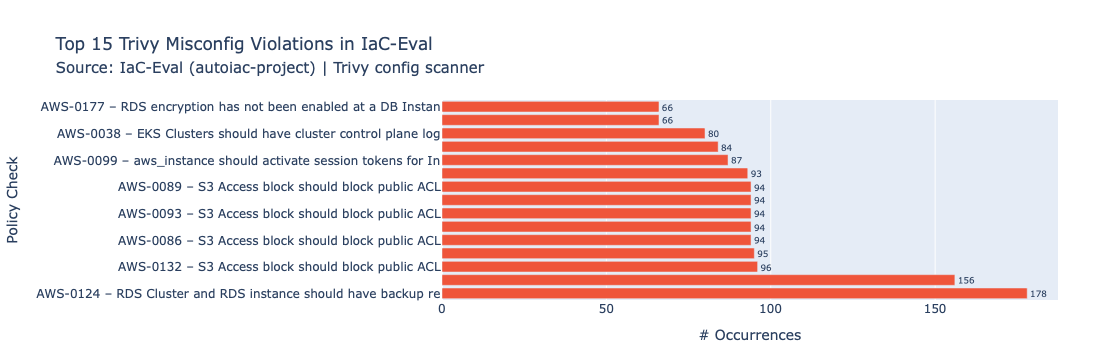

In [16]:
# ── Fig 1 · Top 15 Trivy violations ──────────────────────────────────────────
top15 = top_trivy_violations.head(15).copy()
top15['label'] = top15.apply(
    lambda r: f"{r['check_id']} – {str(r['check_title'])[:50]}", axis=1
)

fig_top = go.Figure(go.Bar(
    x=top15['count'],
    y=top15['label'],
    orientation='h',
    text=top15['count'],
    textposition='outside',
    cliponaxis=False,
    marker_color='#EF553B',
))
fig_top.update_layout(
    title="Top 15 Trivy Misconfig Violations in IaC-Eval<br>"
          "<span style='font-size:15px;font-weight:normal;'>"
          "Source: IaC-Eval (autoiac-project) | Trivy config scanner</span>",
    xaxis_title='# Occurrences',
    yaxis_title='Policy Check',
    margin=dict(l=380, r=60, t=100, b=60),
    autosize=True,
)
fig_top.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_top15_violations.png'), scale=2)
fig_top.show()


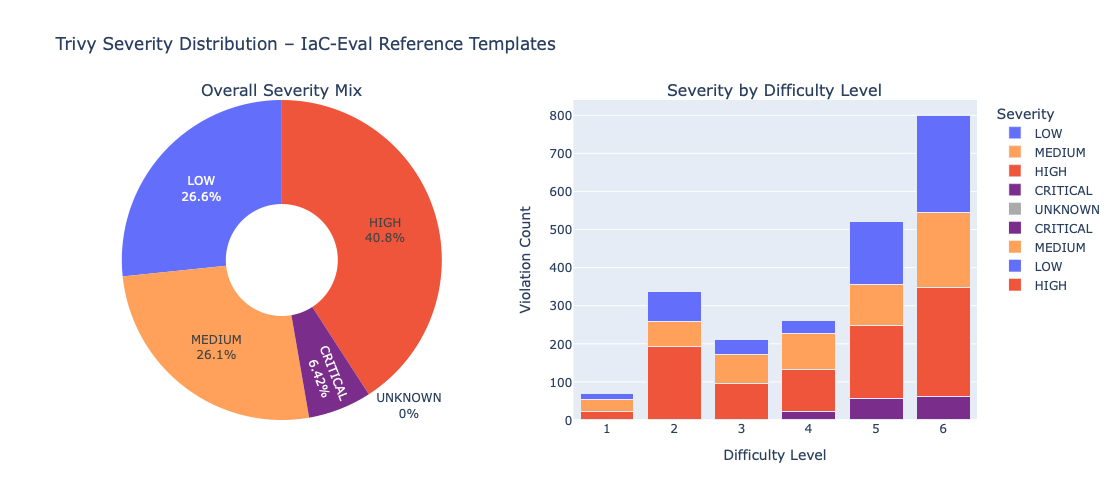

In [20]:
# ── Fig 2 · Severity breakdown ────────────────────────────────────────────────
sev_totals = {
    'CRITICAL': int(df_trivy['severity_critical'].sum()),
    'HIGH':     int(df_trivy['severity_high'].sum()),
    'MEDIUM':   int(df_trivy['severity_medium'].sum()),
    'LOW':      int(df_trivy['severity_low'].sum()),
    'UNKNOWN':  int(df_trivy['severity_unknown'].sum()),
}
sev_colors = {
    'CRITICAL': '#7B2D8B', 'HIGH': '#EF553B',
    'MEDIUM':   '#FFA15A', 'LOW':  '#636EFA', 'UNKNOWN': '#AAAAAA'
}

fig_sev = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'bar'}]],
    subplot_titles=('Overall Severity Mix', 'Severity by Difficulty Level'),
)

# Pie
fig_sev.add_trace(go.Pie(
    labels=list(sev_totals.keys()),
    values=list(sev_totals.values()),
    marker_colors=[sev_colors[s] for s in sev_totals],
    hole=0.35,
    textinfo='label+percent',
), row=1, col=1)

# Stacked bar
for sev, col_name in [
    ('CRITICAL', 'total_critical'), ('HIGH', 'total_high'),
    ('MEDIUM',   'total_medium'),   ('LOW',  'total_low'),
]:
    fig_sev.add_trace(go.Bar(
        x=trivy_summary[_DIFF_COL],
        y=trivy_summary[col_name],
        name=sev,
        marker_color=sev_colors[sev],
    ), row=1, col=2)

fig_sev.update_layout(
    title='Trivy Severity Distribution – IaC-Eval Reference Templates',
    barmode='stack',
    xaxis_title='Difficulty Level',
    yaxis_title='Violation Count',
    legend_title='Severity',
    height=500,
)
fig_sev.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_severity_distribution.png'), scale=2)
fig_sev.show()


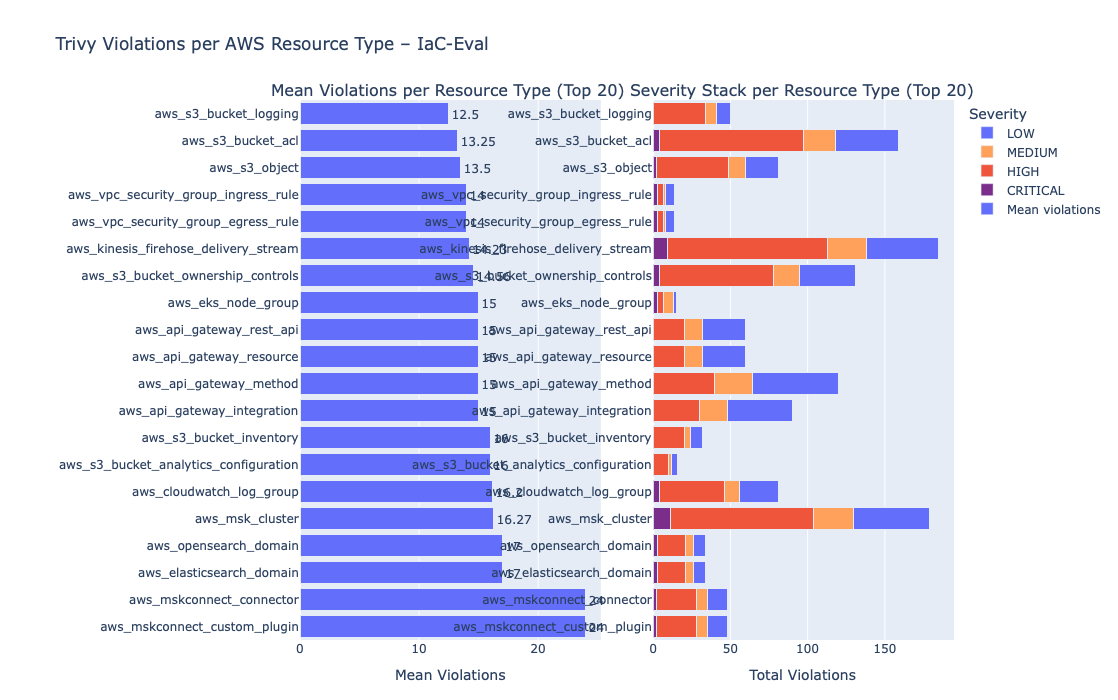

In [22]:
# ── Fig 3 · Per-resource-type analysis ───────────────────────────────────────
# Explode multi-resource scenarios (Resource col is comma-separated)
df_res_exploded = df_trivy.copy()
df_res_exploded[_RES_COL] = df_res_exploded[_RES_COL].str.split(r',\s*')
df_res_exploded = df_res_exploded.explode(_RES_COL)
df_res_exploded[_RES_COL] = df_res_exploded[_RES_COL].str.strip()

res_summary = (
    df_res_exploded.groupby(_RES_COL)
    .agg(
        scenario_count  = (_CODE_COL,             'count'),
        mean_violations = ('failed_checks',        'mean'),
        mean_swvs       = ('swvs',                 'mean'),
        pct_compliant   = ('filtered_compliance',  'mean'),
        total_critical  = ('severity_critical',    'sum'),
        total_high      = ('severity_high',        'sum'),
        total_medium    = ('severity_medium',      'sum'),
        total_low       = ('severity_low',         'sum'),
    )
    .reset_index()
    .sort_values('mean_violations', ascending=False)
)
res_summary['pct_compliant'] = (res_summary['pct_compliant'] * 100).round(1)
res_summary['mean_violations']= res_summary['mean_violations'].round(2)
res_summary['mean_swvs']      = res_summary['mean_swvs'].round(2)

# Top 20 by mean violations
top_res = res_summary.head(20)

fig_res = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Mean Violations per Resource Type (Top 20)',
        'Severity Stack per Resource Type (Top 20)',
    ),
    horizontal_spacing=0.08,
)

# Mean violations bar
fig_res.add_trace(go.Bar(
    x=top_res['mean_violations'],
    y=top_res[_RES_COL],
    orientation='h',
    name='Mean violations',
    marker_color='#636EFA',
    text=top_res['mean_violations'],
    textposition='outside',
    cliponaxis=False,
), row=1, col=1)

# Stacked severity bar (absolute counts)
for sev, col_name in [
    ('CRITICAL', 'total_critical'), ('HIGH', 'total_high'),
    ('MEDIUM',   'total_medium'),   ('LOW',  'total_low'),
]:
    fig_res.add_trace(go.Bar(
        x=top_res[col_name],
        y=top_res[_RES_COL],
        orientation='h',
        name=sev,
        marker_color=sev_colors[sev],
        showlegend=True,
    ), row=1, col=2)

fig_res.update_layout(
    title='Trivy Violations per AWS Resource Type – IaC-Eval',
    barmode='stack',
    height=700,
    margin=dict(l=300, r=80, t=100, b=60),
    legend_title='Severity',
)
fig_res.update_xaxes(title_text='Mean Violations', row=1, col=1)
fig_res.update_xaxes(title_text='Total Violations', row=1, col=2)

fig_res.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_per_resource_type.png'), scale=2)
fig_res.show()


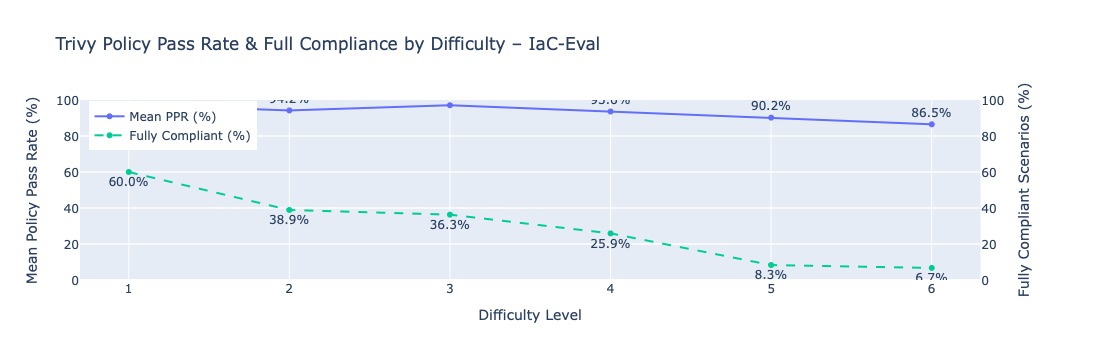

In [24]:
# ── Fig 4 · PPR & Compliance by difficulty ────────────────────────────────────
fig_ppr = make_subplots(specs=[[{'secondary_y': True}]])

fig_ppr.add_trace(go.Scatter(
    x=trivy_summary[_DIFF_COL],
    y=trivy_summary['mean_ppr'],
    mode='lines+markers+text',
    text=trivy_summary['mean_ppr'].apply(lambda v: f'{v:.1f}%'),
    textposition='top center',
    name='Mean PPR (%)',
    line=dict(color='#636EFA', width=2),
), secondary_y=False)

fig_ppr.add_trace(go.Scatter(
    x=trivy_summary[_DIFF_COL],
    y=trivy_summary['pct_compliant'],
    mode='lines+markers+text',
    text=trivy_summary['pct_compliant'].apply(lambda v: f'{v:.1f}%'),
    textposition='bottom center',
    name='Fully Compliant (%)',
    line=dict(color='#00CC96', width=2, dash='dash'),
), secondary_y=True)

fig_ppr.update_layout(
    title='Trivy Policy Pass Rate & Full Compliance by Difficulty – IaC-Eval',
    xaxis_title='Difficulty Level',
    legend=dict(x=0.01, y=0.99),
)
fig_ppr.update_yaxes(title_text='Mean Policy Pass Rate (%)', secondary_y=False, range=[0, 100])
fig_ppr.update_yaxes(title_text='Fully Compliant Scenarios (%)', secondary_y=True, range=[0, 100])

fig_ppr.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_ppr_compliance_by_difficulty.png'), scale=2)
fig_ppr.show()
